# 4_5. SVM w praktyce: rozpoznawanie cyfr z obrazków

W poprzednich notebookach granice decyzyjne widzieliśmy w 1D albo 2D. W praktyce SVM często pracuje w przestrzeni, której nie da się narysować. Tutaj każdy obrazek cyfry ma **64 cechy**: jasności pikseli z siatki 8×8.

To jest ważny krok dydaktyczny: przechodzimy od „ładnej granicy na rysunku” do normalnego workflow uczenia maszynowego.

Cel:

1. zobaczyć, jak wygląda praktyczne użycie SVM,
2. porównać kernel liniowy i RBF,
3. pokazać, dlaczego potrzebne są skalowanie, zbiór testowy i strojenie hiperparametrów,
4. zobaczyć, jak SVM działa w problemie wieloklasowym,
5. przejść od samego wyniku accuracy do macierzy pomyłek i analizy błędów,
6. porównać SVM z drzewem decyzyjnym i metodami drzewowymi.

W tym notebooku granicy decyzyjnej nie rysujemy bezpośrednio, bo 64-wymiarowej granicy nie da się sensownie pokazać na płaskim wykresie. Zamiast tego patrzymy na jakość predykcji i diagnostykę modelu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## 1. Dane: obrazy cyfr jako wektory cech

Zbiór `digits` jest niewielki, ale już dużo bardziej realistyczny niż XOR: mamy 10 klas i 64 cechy na obserwację. Model nie widzi „obrazka” tak jak człowiek — widzi wektor liczb.

,liczba obrazków,liczba cech,liczba klas,klasy
0,1797,64,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


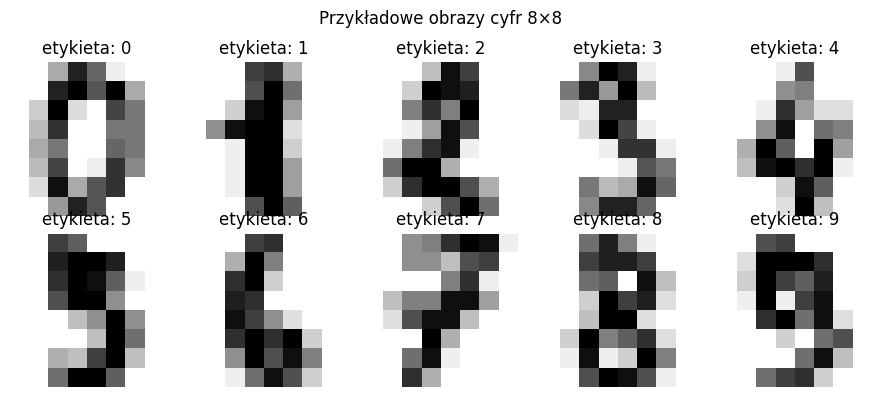

In [2]:
digits = load_digits()
X = digits.data          # kształt: (liczba_obrazków, 64)
y = digits.target        # etykiety: 0, 1, ..., 9
images = digits.images   # kształt: (liczba_obrazków, 8, 8), wygodne do rysowania

summary = pd.DataFrame({
    'liczba obrazków': [X.shape[0]],
    'liczba cech': [X.shape[1]],
    'liczba klas': [len(np.unique(y))],
    'klasy': [np.unique(y).tolist()],
})
display(summary)

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.flatnonzero(y == digit)[0]
    ax.imshow(images[idx], cmap='gray_r')
    ax.set_title(f'etykieta: {digit}')
    ax.axis('off')
plt.suptitle('Przykładowe obrazy cyfr 8×8')
plt.tight_layout()
plt.show()

## 2. Podział na train/test

W przykładach geometrycznych łatwo niechcący oceniać model na tych samych punktach, na których był uczony. W praktyce interesuje nas generalizacja, więc odkładamy część danych jako zbiór testowy.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pd.DataFrame({
    'zbiór': ['train', 'test'],
    'liczba przykładów': [len(X_train), len(X_test)],
})

,zbiór,liczba przykładów
0,train,1347
1,test,450


## 3. Pipeline: skalowanie + SVC

SVM jest wrażliwy na skale cech, szczególnie przy kernelu RBF, bo odległości między punktami wchodzą bezpośrednio do funkcji kernela:

$$
K(x,z)=\exp(-\gamma \lVert x-z\rVert^2).
$$

Jeśli jedna cecha ma wartości rzędu tysięcy, a inna rzędu jedności, to odległość będzie zdominowana przez tę pierwszą cechę. Dlatego w praktyce prawie zawsze łączymy SVM ze skalowaniem.

Używamy `Pipeline`, bo to zabezpiecza nas przed przeciekiem danych:

```text
StandardScaler uczy średnie i odchylenia tylko na treningu,
potem tym samym przekształceniem transformuje walidację/test.
```

To jest poprawny praktyczny schemat:

```text
train data → fit scaler → fit SVC
valid/test → transform scalerem z treningu → predict SVC
```

In [4]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    svc = model.named_steps['svc']
    return {
        'model': name,
        'accuracy test': accuracy_score(y_test, pred),
        'macro F1 test': f1_score(y_test, pred, average='macro'),
        'liczba support vectors': len(svc.support_) if hasattr(svc, 'support_') else np.nan,
    }

models = {
    'SVC linear': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear', C=1)),
    ]),
    'SVC RBF, ustawienia domyślne': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1, gamma='scale')),
    ]),
}

results = [evaluate_model(name, model, X_train, X_test, y_train, y_test) for name, model in models.items()]
display(pd.DataFrame(results).round(3))

,model,accuracy test,macro F1 test,liczba support vectors
0,SVC linear,0.98,0.98,416
1,"SVC RBF, ustawienia domyślne",0.98,0.98,716


### Jak czytać pierwsze wyniki?

- `accuracy test` mówi, jaki procent obrazów został sklasyfikowany poprawnie.
- `macro F1 test` liczy F1 osobno dla każdej cyfry i uśrednia klasy równo. To jest przydatne, gdy klasy mogłyby mieć różne liczności.
- `liczba support vectors` mówi, ile przykładów model zachował jako istotne dla granicy. Im więcej support vectors, tym kosztowniejsza może być predykcja i tym bardziej model opiera się na konkretnych przykładach treningowych.

Na tym etapie porównujemy tylko proste ustawienia. Prawdziwy dobór `C` i `gamma` robimy niżej przez walidację krzyżową.

## 4. Dobór `C` i `gamma` przez walidację krzyżową

Teraz robimy to, czego zwykle brakuje w czysto intuicyjnych przykładach: nie wybieramy parametrów „na oko”, tylko sprawdzamy kilka kombinacji na walidacji krzyżowej.

- `C` reguluje karę za naruszenia marginesu,
- `gamma` reguluje lokalność kernela RBF,
- walidacja krzyżowa ocenia parametry na kilku podziałach treningu,
- wynik końcowy raportujemy dopiero na zbiorze testowym, którego model nie widział przy wyborze parametrów.

To chroni przed zbyt optymistycznym wynikiem. Gdybyśmy dobrali parametry bezpośrednio pod test, test przestałby być uczciwym sprawdzianem generalizacji.

In [5]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf')),
])

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1],
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
)
grid.fit(X_train, y_train)

cv_results = pd.DataFrame(grid.cv_results_)
cols = ['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
display(cv_results[cols].sort_values('rank_test_score').head(10).round(4))

print('Najlepsze parametry:', grid.best_params_)
print('Najlepszy średni macro F1 w CV:', round(grid.best_score_, 4))

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
10,10.0,0.01,0.984,9.000e-04,1
8,10.0,scale,0.982,3.500e-03,2
4,1.0,scale,0.982,5.400e-03,3
9,10.0,0.001,0.978,1.800e-03,4
6,1.0,0.01,0.977,6.300e-03,5
5,1.0,0.001,0.933,3.200e-03,6
11,10.0,0.1,0.932,4.700e-03,7
7,1.0,0.1,0.930,2.800e-03,8
0,0.1,scale,0.913,7.000e-03,9
2,0.1,0.01,0.913,6.300e-03,10


Najlepsze parametry: {'svc__C': 10, 'svc__gamma': 0.01}
Najlepszy średni macro F1 w CV: 0.9836


### Jak interpretować tabelę z `GridSearchCV`?

- `mean_test_score` to średni wynik walidacyjny dla danej kombinacji parametrów.
- `std_test_score` pokazuje, jak bardzo wynik zmieniał się między foldami.
- `rank_test_score = 1` oznacza najlepszą kombinację w badanej siatce.

Nie chodzi o to, żeby zapamiętać jedną idealną wartość `C` lub `gamma`. Chodzi o workflow: parametry dobieramy na walidacji, a test zostawiamy na koniec.

## 5. Ocena końcowa na zbiorze testowym

Dopiero teraz patrzymy na test. To jest uczciwsza odpowiedź na pytanie: „czy SVM działa na nowych danych?”.

Raport klasyfikacji pokazuje wynik osobno dla każdej cyfry. Macierz pomyłek odpowiada na pytanie: które cyfry model myli ze sobą najczęściej?

Jak czytać macierz pomyłek:

```text
wiersz    = prawdziwa cyfra,
kolumna   = cyfra przewidziana przez model,
przekątna = poprawne klasyfikacje,
poza przekątną = konkretne typy pomyłek.
```

To jest szczególnie przydatne przy wielu klasach, bo dwa modele mogą mieć podobne `accuracy`, ale mylić zupełnie inne cyfry.

Accuracy test: 0.9822
Macro F1 test: 0.9821

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.96      0.98      0.97        46
           2       1.00      1.00      1.00        44
           3       1.00      1.00      1.00        46
           4       0.96      0.98      0.97        45
           5       1.00      0.98      0.99        46
           6       0.98      1.00      0.99        45
           7       0.96      1.00      0.98        45
           8       1.00      0.93      0.96        43
           9       0.98      0.96      0.97        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



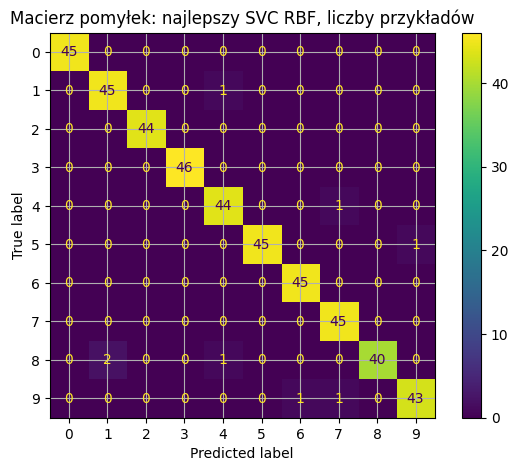

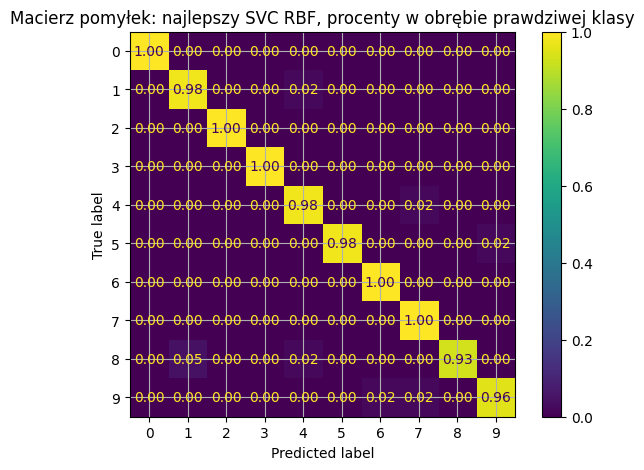

In [6]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print('Accuracy test:', round(accuracy_score(y_test, y_pred), 4))
print('Macro F1 test:', round(f1_score(y_test, y_pred, average='macro'), 4))
print()
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=np.arange(10),
    display_labels=np.arange(10),
    values_format='d',
)
plt.title('Macierz pomyłek: najlepszy SVC RBF, liczby przykładów')
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=np.arange(10),
    display_labels=np.arange(10),
    normalize='true',
    values_format='.2f',
)
plt.title('Macierz pomyłek: najlepszy SVC RBF, procenty w obrębie prawdziwej klasy')
plt.show()


### 5b. Ta sama macierz w procentach

Macierz zliczeń mówi, ile było konkretnych pomyłek. Czasem wygodniej przeliczyć każdy wiersz na procenty: wtedy każdy wiersz odpowiada jednej prawdziwej cyfrze i sumuje się do 100%.

To pomaga odpowiedzieć na pytania typu: „jaki procent prawdziwych ósemek model pomylił z trójkami?”.

In [7]:
cm_counts = confusion_matrix(y_test, y_pred, labels=np.arange(10))
cm_percent = cm_counts / cm_counts.sum(axis=1, keepdims=True)
cm_percent_df = pd.DataFrame(
    np.round(100 * cm_percent, 1),
    index=[f'true {i}' for i in range(10)],
    columns=[f'pred {i}' for i in range(10)],
)
display(cm_percent_df)
cm_no_diag = cm_counts.copy()
np.fill_diagonal(cm_no_diag, 0)

mistake_pairs = []
for true_label in range(10):
    for pred_label in range(10):
        count = cm_no_diag[true_label, pred_label]
        if count > 0:
            mistake_pairs.append({
                'prawdziwa cyfra': true_label,
                'przewidziana cyfra': pred_label,
                'liczba pomyłek': int(count),
            })

print('Najczęstsze pary pomyłek poza przekątną:')
if mistake_pairs:
    display(pd.DataFrame(mistake_pairs).sort_values('liczba pomyłek', ascending=False).head(10))
else:
    print('Brak pomyłek w tym podziale danych.')


,pred 0,pred 1,pred 2,pred 3,pred 4,pred 5,pred 6,pred 7,pred 8,pred 9
true 0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
true 1,0.0,97.8,0.0,0.0,2.2,0.0,0.0,0.0,0.0,0.0
true 2,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
true 3,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
true 4,0.0,0.0,0.0,0.0,97.8,0.0,0.0,2.2,0.0,0.0
true 5,0.0,0.0,0.0,0.0,0.0,97.8,0.0,0.0,0.0,2.2
true 6,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
true 7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
true 8,0.0,4.7,0.0,0.0,2.3,0.0,0.0,0.0,93.0,0.0
true 9,0.0,0.0,0.0,0.0,0.0,0.0,2.2,2.2,0.0,95.6


Najczęstsze pary pomyłek poza przekątną:


,prawdziwa cyfra,przewidziana cyfra,liczba pomyłek
3,8,1,2
1,4,7,1
0,1,4,1
2,5,9,1
4,8,4,1
5,9,6,1
6,9,7,1


## 6. Diagnostyka: ile support vectors ma model?

W SVM support vectors są przykładami treningowymi, które realnie wpływają na granicę decyzyjną.

W małym przykładzie 2D można je obrysować na wykresie. W problemie 64-wymiarowym wygodniej popatrzeć na liczby:

- ile support vectors ma model łącznie,
- ile przypada na poszczególne klasy,
- jaki procent treningu stał się support vectors.

Dużo support vectors nie musi oznaczać błędu, ale jest sygnałem, że problem jest trudny albo granica jest dość złożona.

In [8]:
svc_best = best_model.named_steps['svc']
sv_summary = pd.DataFrame({
    'klasa': np.arange(len(svc_best.n_support_)),
    'liczba support vectors': svc_best.n_support_,
})
sv_summary.loc['razem'] = ['wszystkie', int(svc_best.n_support_.sum())]
display(sv_summary)

print('Procent przykładów treningowych będących support vectors:', round(100 * len(svc_best.support_) / len(X_train), 2), '%')

,klasa,liczba support vectors
0,0,34
1,1,73
2,2,61
3,3,61
4,4,65
5,5,63
6,6,46
7,7,69
8,8,77
9,9,70


Procent przykładów treningowych będących support vectors: 45.95 %


## 7. Jak wyglądają błędy?

Same metryki są potrzebne, ale dydaktycznie warto obejrzeć pomyłki. Przy obrazach cyfr łatwo zobaczyć, że część błędów jest „ludzko zrozumiała”: cyfry bywają nieczytelne albo podobne do innych cyfr.

Liczba błędów na teście: 8 z 450


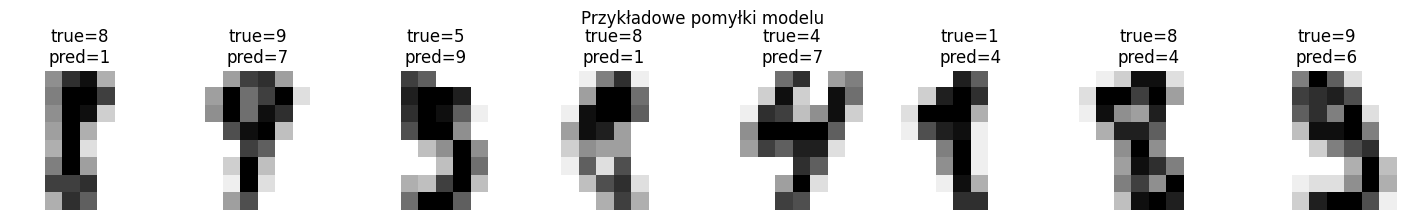

In [9]:
misclassified = np.flatnonzero(y_pred != y_test)
print('Liczba błędów na teście:', len(misclassified), 'z', len(y_test))

if len(misclassified) > 0:
    shown = misclassified[:10]
    fig, axes = plt.subplots(1, len(shown), figsize=(1.8 * len(shown), 2.2))
    if len(shown) == 1:
        axes = [axes]
    for ax, idx in zip(axes, shown):
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r')
        ax.set_title(f'true={y_test[idx]}\npred={y_pred[idx]}')
        ax.axis('off')
    plt.suptitle('Przykładowe pomyłki modelu')
    plt.tight_layout()
    plt.show()
else:
    print('Brak błędów w tym podziale danych.')

## 8. Mini-eksperyment: mapa jakości dla `C` i `gamma`

Zbyt małe `gamma` daje granicę bardzo gładką. Zbyt duże `gamma` może dopasowywać się lokalnie do pojedynczych przykładów. Tabela poniżej pokazuje, że wybór parametrów ma znaczenie nawet wtedy, gdy model i dane są te same.

param_svc__C,0.1,1.0,10.0
param_svc__gamma,,,
0.001,0.180,0.933,0.978
0.010,0.913,0.977,0.984
0.100,0.268,0.930,0.932


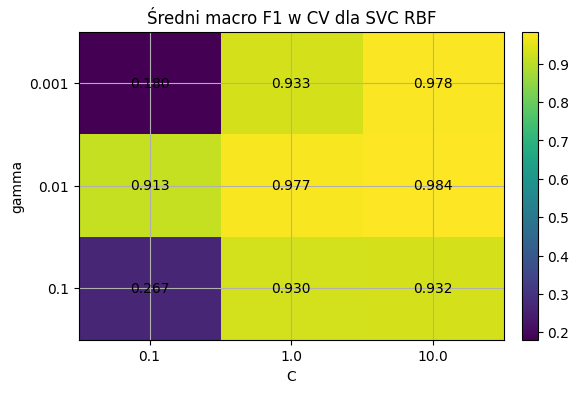

In [10]:
heat = cv_results[cv_results['param_svc__gamma'] != 'scale'].copy()
heat['param_svc__C'] = heat['param_svc__C'].astype(float)
heat['param_svc__gamma'] = heat['param_svc__gamma'].astype(float)
pivot = heat.pivot(index='param_svc__gamma', columns='param_svc__C', values='mean_test_score')
display(pivot.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('C')
ax.set_ylabel('gamma')
ax.set_title('Średni macro F1 w CV dla SVC RBF')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 9. SVM a drzewa decyzyjne i metody drzewowe

SVM i drzewa rozwiązują ten sam typ zadania — **uczenie nadzorowane / klasyfikację** — ale robią to bardzo inaczej.

| aspekt | SVM / SVC | drzewa i metody drzewowe |
|---|---|---|
| podstawowa intuicja | granica z dużym marginesem między klasami | seria reguł typu `cecha <= próg` |
| kształt granicy | liniowa albo gładka/nieliniowa przez kernel | schodkowa, złożona z cięć równoległych do osi cech |
| skalowanie cech | zwykle bardzo ważne, szczególnie dla RBF | zwykle niepotrzebne |
| interpretowalność | liniowy SVM dość prosty, RBF mniej czytelny | pojedyncze drzewo czytelne; las/boosting mniej, ale nadal da się badać ważności cech |
| mocna strona | dane numeryczne, separacja przez odległości, wiele cech | nieliniowe reguły, interakcje, dane tabelaryczne, brak potrzeby skalowania |
| ryzyko | złe `C/gamma` może dać model zbyt gładki albo przeuczony | pojedyncze drzewo łatwo się przeucza; ensemble to stabilizuje |

To nie są metody, które się wykluczają. W praktyce często używa się ich jako **uzupełniających baseline'ów**:

```text
SVM RBF          → dobry model odległościowy po skalowaniu,
Decision Tree    → czytelny model regułowy, ale często niestabilny,
Random Forest    → mocniejsza metoda drzewowa, mniej podatna na wariancję jednego drzewa.
```

Porównanie confusion matrices jest tu bardziej pouczające niż samo `accuracy`, bo pokazuje, czy modele mylą te same cyfry.

,model,accuracy test,macro F1 test,liczba błędów
0,SVC RBF po GridSearch,0.982,0.982,8
3,RandomForest,0.960,0.960,18
1,DecisionTree,0.824,0.823,79
2,DecisionTree max_depth=8,0.813,0.814,84


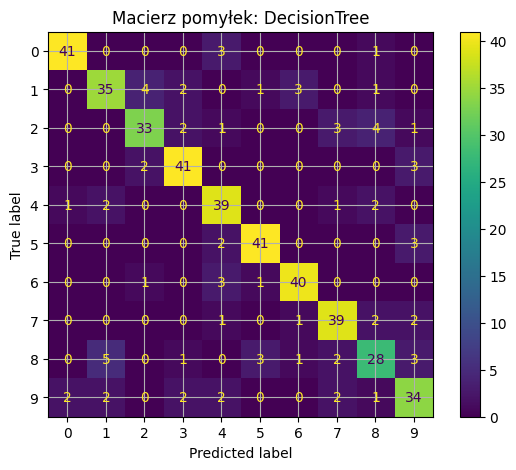

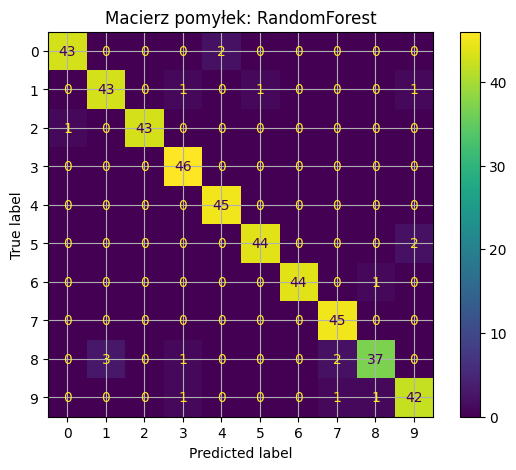

Liczba przykładów, gdzie SVC i RandomForest dają różne predykcje: 17


,prawdziwa cyfra,pred SVC RBF,pred RandomForest
62,0,0,4
101,1,1,3
112,8,8,7
121,0,0,4
194,9,9,8
199,9,9,3
200,6,6,8
230,8,8,7
239,8,8,3
266,4,7,4


In [11]:
from sklearn.base import clone

comparison_models = {
    'SVC RBF po GridSearch': best_model,
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'DecisionTree max_depth=8': DecisionTreeClassifier(max_depth=8, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
}

comparison_rows = []
comparison_preds = {}
for name, estimator in comparison_models.items():
    model = clone(estimator)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    comparison_preds[name] = pred
    comparison_rows.append({
        'model': name,
        'accuracy test': accuracy_score(y_test, pred),
        'macro F1 test': f1_score(y_test, pred, average='macro'),
        'liczba błędów': int(np.sum(pred != y_test)),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('macro F1 test', ascending=False)
display(comparison_df.round(4))

for name in ['DecisionTree', 'RandomForest']:
    ConfusionMatrixDisplay.from_predictions(y_test, comparison_preds[name])
    plt.title(f'Macierz pomyłek: {name}')
    plt.show()

# Dla porównania: gdzie RandomForest i SVC popełniają różne błędy?
svm_pred = comparison_preds['SVC RBF po GridSearch']
rf_pred = comparison_preds['RandomForest']
diff_table = pd.DataFrame({
    'prawdziwa cyfra': y_test,
    'pred SVC RBF': svm_pred,
    'pred RandomForest': rf_pred,
})
diff_table = diff_table[diff_table['pred SVC RBF'] != diff_table['pred RandomForest']]
print('Liczba przykładów, gdzie SVC i RandomForest dają różne predykcje:', len(diff_table))
display(diff_table.head(12))

## 10. Opcjonalny wariant: trudniejsza para cyfr `3` vs `8`

W całym zbiorze model rozpoznaje 10 cyfr naraz. Czasem dydaktycznie warto zawęzić problem do dwóch podobnych klas, żeby zobaczyć bardziej konkretną separację.

Poniżej robimy mini-eksperyment binarny: odróżnianie `3` od `8`. Workflow zostaje ten sam: podział train/test, skalowanie, SVC RBF, dobór parametrów przez CV.

Najlepsze parametry 3 vs 8: {'svc__C': 1, 'svc__gamma': 'scale'}
Accuracy test 3 vs 8: 0.9778
Macro F1 test 3 vs 8: 0.9777


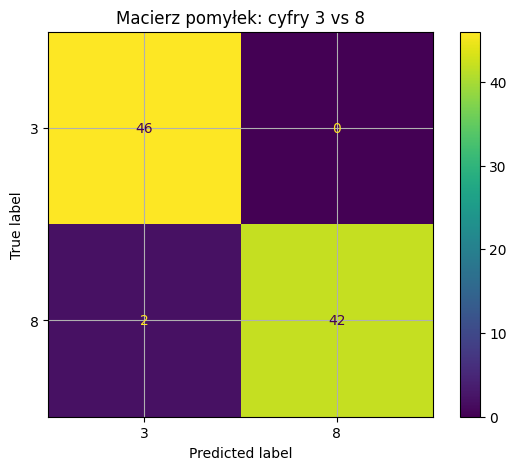

In [12]:
mask_38 = np.isin(y, [3, 8])
X_38 = X[mask_38]
y_38 = y[mask_38]

X38_train, X38_test, y38_train, y38_test = train_test_split(
    X_38, y_38,
    test_size=0.25,
    random_state=42,
    stratify=y_38,
)

pipe_38 = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf')),
])

grid_38 = GridSearchCV(
    pipe_38,
    param_grid={
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 0.001, 0.01, 0.1],
    },
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
)
grid_38.fit(X38_train, y38_train)
pred_38 = grid_38.best_estimator_.predict(X38_test)

print('Najlepsze parametry 3 vs 8:', grid_38.best_params_)
print('Accuracy test 3 vs 8:', round(accuracy_score(y38_test, pred_38), 4))
print('Macro F1 test 3 vs 8:', round(f1_score(y38_test, pred_38, average='macro'), 4))

ConfusionMatrixDisplay.from_predictions(y38_test, pred_38)
plt.title('Macierz pomyłek: cyfry 3 vs 8')
plt.show()

## 11. Co zapamiętać?

- W trudniejszym problemie granicy decyzyjnej nie zobaczymy bezpośrednio, bo dane mają wiele cech.
- SVM wymaga sensownego workflow: skalowanie → train/test → walidacja krzyżowa → dopiero potem test.
- Kernel liniowy jest prostszy i często dobry przy wielu cechach.
- Kernel RBF pozwala budować nieliniowe granice, ale jego elastyczność trzeba kontrolować przez `C` i `gamma`.
- `C` odpowiada za karę za naruszenia marginesu.
- `gamma` w RBF odpowiada za lokalność podobieństwa.
- Support vectors są przykładami, które faktycznie wpływają na granicę; w większym problemie ich liczba jest ważną informacją diagnostyczną.
- Testu używamy dopiero na końcu. Parametrów nie dobieramy na teście.
- Macierz pomyłek jest naturalnym narzędziem dla klasyfikacji nadzorowanej: pokazuje nie tylko ile błędów było, ale jakie klasy zostały pomylone.
- SVM i metody drzewowe warto traktować jako uzupełniające punkty odniesienia: SVM używa marginesów i odległości, drzewa używają reguł progowych.

### Zadania dla studentów

1. Uruchom model bez `StandardScaler` i porównaj wynik.
2. Zwiększ zakres `gamma`, np. dodaj `1`, i sprawdź, czy wynik CV spada.
3. Zrób wersję binarną: odróżnianie `4` od `9` albo `1` od `7`.
4. Porównaj SVC RBF z modelem liniowym po redukcji PCA do 2 wymiarów.
5. Sprawdź, jak zmienia się liczba support vectors dla małego i dużego `C`.
6. Porównaj confusion matrices dla SVC RBF i RandomForest: czy modele mylą te same cyfry?
7. Ogranicz głębokość drzewa (`max_depth`) i sprawdź, jak zmieniają się błędy na macierzy pomyłek.